In [99]:
# imports
import pandas as pd
import geopandas as gpd
from shapely import wkt
import numpy as np
import xarray as xa
from rasterio.features import rasterize
from rasterio.transform import from_origin
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pickle
from shapely.geometry import box
from shapely import make_valid
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

DATA_DIR_FP = Path("/Users/rt582/Desktop/seagrass_mapping/data")
SEAGRASS_EOV_FP = DATA_DIR_FP / "seagrass_eov"
# fps
all_poly_fp = SEAGRASS_EOV_FP / "seagrass_eov_poly_2025.csv"
all_points_fp = SEAGRASS_EOV_FP / "seagrass_eov_points_2025.csv"

processed_poly_fp = (
    SEAGRASS_EOV_FP / "europe_seagrass_gdf_processed.csv"
)  # has species, but doesn't contain the shapes

processed_points_fp = (
    SEAGRASS_EOV_FP / "seagrass_eov_points_2025_processed.csv"
)  # has everything I need

In [2]:
# map seagrass_species to prediction_species_index
species_index_map = {
    1: "Cymodocea nodosa",
    2: "Halophila stipulacea",
    3: "Posidonia oceanica",
    4: "Unspecified",
    5: "Zostera marina",
    6: "Zostera marina and Cymodocea nodosa",
    7: "Zostera noltei",
}
inv_species_index_map = {v: k for k, v in species_index_map.items()}

In [77]:
### load species-specific prediction grid
pred_fp = Path(
    "/Users/rt582/Desktop/seagrass_mapping/output/pixel_grouped/predictions/gam_prediction_grid.nc"
)
pred_ds = xa.open_dataset(pred_fp)

rivers_gdf = gpd.read_file(
    "/Users/rt582/Desktop/seagrass_mapping/data/hotosm_fra_waterways_lines_geojson/hotosm_fra_waterways_lines_geojson.geojson"
)  # for bringing in the Somme

In [148]:
def convert_carbon_density_to_carbon_stock(carbon_density, depth):
    """
    Convert carbon density to carbon stock: from gC/cm3 to MgC/ha
    """
    return carbon_density * depth * 1e8 / 1e6


In [114]:
# Geometry-attributed carbon density (faster):
# assign each polygon/point a carbon value from the raster
# - polygons: mean over touched cells (windowed rasterization, not full-grid)
# - points: value at containing raster cell (vectorized)
# Uses each row's own prediction_species_index


polygon_attributed_fp = SEAGRASS_EOV_FP / "seagrass_eov_gdf_attributed.geojson"
point_attributed_fp = SEAGRASS_EOV_FP / "seagrass_eov_pts_attributed.geojson"


if polygon_attributed_fp.exists() and point_attributed_fp.exists():
    print("Polygon and point attributed files already exist, loading from files...")
    gdf_attributed = gpd.read_file(polygon_attributed_fp)
    pts_attributed = gpd.read_file(point_attributed_fp)
else:
    poly_df_fp = SEAGRASS_EOV_FP / "seagrass_eov_poly_2025_complete.geojson"
    points_df_fp = SEAGRASS_EOV_FP / "seagrass_eov_points_2025_complete.geojson"

    if poly_df_fp.exists() and points_df_fp.exists():
        print("Polygon and point files already exist, loading from files...")
        poly_df = gpd.read_file(poly_df_fp)
        points_df = gpd.read_file(points_df_fp)
    else:
        ### processs the poly csv
        poly_df = pd.read_csv(all_poly_fp)
        # Convert the WKT strings in the 'geom' column to shapely geometry objects
        poly_df["geometry"] = poly_df["geom"].apply(wkt.loads)
        # Create a GeoDataFrame from the DataFrame, specifying the geometry column
        poly_gdf = gpd.GeoDataFrame(poly_df, geometry="geometry")
        # drop geom column
        poly_gdf = poly_gdf.drop(columns=["geom"])
        poly_gdf.set_crs(crs="epsg:3857", inplace=True)
        poly_gdf.to_crs(epsg=4326, inplace=True)  # convert to epsg:4326
        # crop to extent of Europe: lats 30N-60N, lons 10W-40E from multipolygons
        lons = (-20, 30)
        lats = (30, 60)
        poly_gdf = poly_gdf.cx[min(lons) : max(lons), min(lats) : max(lats)]

        # assign seagrass species
        processed_polygon_df = pd.read_csv(
            SEAGRASS_EOV_FP / "europe_seagrass_gdf_processed.csv",
            low_memory=False,  # mixed types
        )
        id_and_species = processed_polygon_df[["id", "seagrass_species"]]
        # merge gdf with processed_gdf on the id column
        poly_gdf = poly_gdf.merge(id_and_species, on="id", how="left")
        # drop rows with no seagrass_species
        poly_gdf = poly_gdf[poly_gdf["seagrass_species"].notna()]
        poly_gdf["prediction_species_index"] = poly_gdf["seagrass_species"].map(
            inv_species_index_map
        )
        # save to file with shapes kept?

        ### process the points csv
        points_df = pd.read_csv(processed_points_fp)
        points_df["geometry"] = points_df["geom"].apply(wkt.loads)
        # Create a GeoDataFrame from the DataFrame, specifying the geometry column
        points_gdf = gpd.GeoDataFrame(points_df, geometry="geometry")
        # drop geom column
        points_gdf = points_gdf.drop(columns=["geom"])
        points_gdf.set_crs(crs="epsg:3857", inplace=True)
        points_gdf.to_crs(epsg=4326, inplace=True)  # convert to epsg:4326
        # create lat and lon columns for selective retention of raster cells
        points_gdf["lat"] = points_gdf["geometry"].y
        points_gdf["lon"] = points_gdf["geometry"].x
        points_gdf = points_gdf[points_gdf["seagrass_species"].notna()]
        points_gdf["prediction_species_index"] = points_gdf["seagrass_species"].map(
            inv_species_index_map
        )
        # save to file with shapes kept
        print("Saving points to file...")
        poly_gdf.to_file(poly_df_fp, driver="GeoJSON")
        points_gdf.to_file(points_df_fp, driver="GeoJSON")
    # -----------------------------
    # User controls
    # -----------------------------
    polygon_stat = "mean"  # implemented: "mean"
    all_touched = True

    # -----------------------------
    # Preconditions
    # -----------------------------

    req_col = "prediction_species_index"
    if req_col not in poly_gdf.columns or req_col not in points_gdf.columns:
        raise KeyError("Both gdf and pts_gdf must contain `prediction_species_index`.")

    # Harmonize CRS
    gdf_local = poly_gdf.copy()
    pts_local = points_gdf.copy()
    if gdf_local.crs is None:
        gdf_local = gdf_local.set_crs("EPSG:4326")
    if pts_local.crs is None:
        pts_local = pts_local.set_crs("EPSG:4326")
    if str(gdf_local.crs).lower() not in {"epsg:4326", "4326"}:
        gdf_local = gdf_local.to_crs(4326)
    if str(pts_local.crs).lower() not in {"epsg:4326", "4326"}:
        pts_local = pts_local.to_crs(4326)

    # Keep valid rows and indices
    gdf_local = gdf_local[
        gdf_local.geometry.notna() & ~gdf_local.geometry.is_empty
    ].copy()
    pts_local = pts_local[
        pts_local.geometry.notna() & ~pts_local.geometry.is_empty
    ].copy()
    gdf_local = gdf_local[gdf_local[req_col].notna()].copy()
    pts_local = pts_local[pts_local[req_col].notna()].copy()
    gdf_local[req_col] = gdf_local[req_col].astype(int)
    pts_local[req_col] = pts_local[req_col].astype(int)

    # Prediction cube (sorted coordinates)
    lon_asc = np.sort(np.asarray(pred_ds["lon"].values))
    lat_asc = np.sort(np.asarray(pred_ds["lat"].values))
    ny, nx = len(lat_asc), len(lon_asc)

    pred_all = pred_ds["prediction"].sel(lon=lon_asc, lat=lat_asc)
    _fill = pred_all.attrs.get("_FillValue", -9999)
    pred_all = pred_all.where(pred_all != _fill)

    species_coord = np.asarray(pred_all["prediction_species_index"].values)
    species_set = set(int(v) for v in species_coord)

    # Grid edges
    lon_step = float(np.median(np.diff(lon_asc)))
    lat_step = float(np.median(np.diff(lat_asc)))
    lon_edges = np.r_[lon_asc - lon_step / 2, lon_asc[-1] + lon_step / 2]
    lat_edges = np.r_[lat_asc - lat_step / 2, lat_asc[-1] + lat_step / 2]

    # Cache species arrays once
    pred_by_species = {
        int(sp): pred_all.sel(prediction_species_index=int(sp))
        .transpose("lat", "lon")
        .values
        for sp in species_set
    }

    # -----------------------------
    # Polygon attribution: mean over touched cells (FAST windowed rasterization)
    # -----------------------------
    poly_values = np.full(len(gdf_local), np.nan, dtype=float)
    for row_pos, (_, row) in tqdm(
        enumerate(gdf_local.iterrows()),
        total=len(gdf_local),
        desc="Polygons",
    ):
        sp = int(row[req_col])
        if sp not in pred_by_species:
            continue

        geom = row.geometry
        xmin, ymin, xmax, ymax = geom.bounds

        # Bounding index window in grid space
        ix0 = max(0, np.searchsorted(lon_edges, xmin, side="right") - 1)
        ix1 = min(nx - 1, np.searchsorted(lon_edges, xmax, side="left"))
        iy0 = max(0, np.searchsorted(lat_edges, ymin, side="right") - 1)
        iy1 = min(ny - 1, np.searchsorted(lat_edges, ymax, side="left"))

        if ix1 < ix0 or iy1 < iy0:
            continue

        win_w = ix1 - ix0 + 1
        win_h = iy1 - iy0 + 1

        # Window transform: north edge is top edge of highest-lat row in the window
        win_transform = from_origin(
            west=float(lon_edges[ix0]),
            north=float(lat_edges[iy1 + 1]),
            xsize=float(lon_step),
            ysize=float(lat_step),
        )

        mask_desc = rasterize(
            [(geom, 1)],
            out_shape=(win_h, win_w),
            transform=win_transform,
            fill=0,
            all_touched=all_touched,
            dtype="uint8",
        )

        # Flip to ascending-lat order to match pred array slicing
        mask = np.flipud(mask_desc).astype(bool)
        if not mask.any():
            continue

        pred_window = pred_by_species[sp][iy0 : iy1 + 1, ix0 : ix1 + 1]
        vals = pred_window[mask]
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        if polygon_stat == "mean":
            poly_values[row_pos] = float(vals.mean())
        else:
            raise ValueError("Only polygon_stat='mean' is currently implemented.")

    # -----------------------------
    # Point attribution: containing cell value (FAST vectorized)
    # -----------------------------
    point_values = np.full(len(pts_local), np.nan, dtype=float)

    x = pts_local.geometry.x.to_numpy()
    y = pts_local.geometry.y.to_numpy()
    sp_arr = pts_local[req_col].to_numpy(dtype=int)

    cols = np.searchsorted(lon_edges, x, side="right") - 1
    rows = np.searchsorted(lat_edges, y, side="right") - 1

    in_bounds = (cols >= 0) & (cols < nx) & (rows >= 0) & (rows < ny)
    valid_sp = np.isin(sp_arr, list(species_set))
    valid = in_bounds & valid_sp

    for sp in tqdm(np.unique(sp_arr[valid]), desc="Point species groups"):
        idx = np.where(valid & (sp_arr == sp))[0]
        if idx.size == 0:
            continue
        arr = pred_by_species[int(sp)]
        point_values[idx] = arr[rows[idx], cols[idx]]

    # Attach outputs
    gdf_attributed = gdf_local.copy()
    pts_attributed = pts_local.copy()

    poly_col = "carbon_density_from_raster"
    pt_col = "carbon_density_from_raster"

    gdf_attributed[poly_col] = poly_values
    pts_attributed[pt_col] = point_values

    print(
        f"Polygons attributed: {int(np.isfinite(poly_values).sum()):,} / {len(poly_values):,}"
    )
    print(
        f"Points attributed:   {int(np.isfinite(point_values).sum()):,} / {len(point_values):,}"
    )

    # Optional quick previews
    display(
        gdf_attributed[["seagrass_species", "prediction_species_index", poly_col]].head(
            5
        )
    )
    display(
        pts_attributed[["seagrass_species", "prediction_species_index", pt_col]].head(5)
    )
    # save to file, preserving polygon information
    gdf_attributed.to_file(polygon_attributed_fp, driver="GeoJSON")
    pts_attributed.to_file(point_attributed_fp, driver="GeoJSON")

Polygon and point attributed files already exist, loading from files...


In [ ]:
eez_gdf = gpd.read_file(DATA_DIR_FP / "eezs" / "World_EEZ_v12_20231025/eez_v12.shp")

,MRGID,GEONAME,MRGID_TER1,POL_TYPE,MRGID_SOV1,TERRITORY1,ISO_TER1,SOVEREIGN1,MRGID_TER2,MRGID_SOV2,...,ISO_SOV1,ISO_SOV2,ISO_SOV3,UN_SOV1,UN_SOV2,UN_SOV3,UN_TER1,UN_TER2,UN_TER3,geometry
0,8444,United States Exclusive Economic Zone (America...,8670.0,200NM,2204,American Samoa,ASM,United States,NaN,NaN,...,USA,None,None,840,NaN,NaN,16.0,NaN,NaN,"POLYGON ((-166.64112 -17.55527, -166.64194 -17..."
1,8379,British Exclusive Economic Zone (Ascension),8620.0,200NM,2208,Ascension,SHN,United Kingdom,NaN,NaN,...,GBR,None,None,826,NaN,NaN,654.0,NaN,NaN,"POLYGON ((-10.93328 -7.88745, -10.93324 -7.889..."
2,8446,New Zealand Exclusive Economic Zone (Cook Isla...,8672.0,200NM,2227,Cook Islands,COK,New Zealand,NaN,NaN,...,NZL,None,None,554,NaN,NaN,184.0,NaN,NaN,"POLYGON ((-159.27579 -5.80051, -158.38466 -6.3..."
3,8389,Overlapping claim Falkland / Malvinas Islands:...,8623.0,Overlapping claim,2208,Falkland / Malvinas Islands,FLK,United Kingdom,8623.0,2149.0,...,GBR,ARG,None,826,32.0,NaN,238.0,238.0,NaN,"POLYGON ((-58.54196 -56.22782, -61.62049 -53.7..."
4,8440,French Exclusive Economic Zone (French Polynesia),8656.0,200NM,17,French Polynesia,PYF,France,NaN,NaN,...,FRA,None,None,250,NaN,NaN,258.0,NaN,NaN,"MULTIPOLYGON (((-135.92820 -7.89810, -135.9265..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,64460,Overlapping claim: Iraq / Iran,2125.0,Overlapping claim,2125,Iraq,IRQ,Iraq,2126.0,2126.0,...,IRQ,IRN,None,368,364.0,NaN,368.0,364.0,NaN,"POLYGON ((48.74283 29.85650, 48.73551 29.84191..."
281,64430,Overlapping claim: Egypt / Libya,3868.0,Overlapping claim,3868,Egypt,EGY,Egypt,2194.0,2194.0,...,EGY,LBY,None,818,434.0,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((25.23258 31.65889, 25.25045 31..."
282,64431,Overlapping claim: Belize / Honduras,8681.0,Overlapping claim,8681,Belize,BLZ,Belize,2103.0,2103.0,...,BLZ,HND,None,84,340.0,NaN,NaN,NaN,NaN,"POLYGON ((-88.13747 16.27476, -88.12082 16.266..."
283,64459,Joint regime area: Norway / Russia,2252.0,Joint regime,2252,Norway,NOR,Norway,2240.0,2240.0,...,NOR,RUS,None,578,643.0,NaN,578.0,643.0,NaN,"POLYGON ((35.89632 73.03558, 35.93074 73.05676..."


In [ ]:
# Spatial join: add EEZ info to polygons and points based on geometry
print("Intersecting polygons with EEZs...")
gdf_attributed_joined = gpd.sjoin(
    gdf_attributed,
    eez_gdf[
        [
            "geometry",
            "GEONAME",
            "TERRITORY1",
            "SOVEREIGN1",
        ]
    ],
    how="left",
    predicate="intersects",
)
print("Intersecting points with EEZs...")
pts_attributed_joined = gpd.sjoin(
    pts_attributed,
    eez_gdf[
        [
            "geometry",
            "GEONAME",
            "TERRITORY1",
            "SOVEREIGN1",
        ]
    ],
    how="left",
    predicate="within",
)

# drop the extra index_right and duplicate geometry columns if needed
gdf_attributed_joined = gdf_attributed_joined.drop(
    columns=[
        col
        for col in gdf_attributed.columns
        if col.startswith("index_right") or col == "geometry_right"
    ],
    errors="ignore",
)

In [176]:
# remove Tunisia points – these are incredibly large and will throw off the area calculations
gdf_attributed_joined = gdf_attributed_joined[
    gdf_attributed_joined["SOVEREIGN1"] != "Tunisia"
]
pts_attributed_joined = pts_attributed_joined.drop(
    columns=[
        col
        for col in pts_attributed.columns
        if col.startswith("index_right") or col == "geometry_right"
    ],
    errors="ignore",
)


In [201]:
# The area calculated after reprojecting to EPSG:3857 will be in square meters (m^2)
# Calculate the area of the seagrass polygons for each EEZ.
ea_gdf_attributed_joined = gdf_attributed_joined.to_crs(epsg=3857)
ea_pts_attributed_joined = pts_attributed_joined.to_crs(epsg=3857)

g = ea_gdf_attributed_joined.copy()
p = ea_pts_attributed_joined.copy()

# there are some crazy values in the carbon density raster: clip between 0 and 0.25
g["carbon_density_from_raster"] = g["carbon_density_from_raster"].clip(0, 0.25)
g["area_ha"] = g.geometry.area / 1e4
national_areas = g.groupby("TERRITORY1")["area_ha"].sum()
g["stock_Mg_ha"] = convert_carbon_density_to_carbon_stock(
    g["carbon_density_from_raster"], 100
)

p["stock_Mg"] = convert_carbon_density_to_carbon_stock(
    p["carbon_density_from_raster"], 100
)

g["stock_Mg"] = g["stock_Mg_ha"] * g["area_ha"]

national_stocks = g.groupby(["TERRITORY1", "seagrass_species"])["stock_Mg"].sum()
# calculate the total carbon stock for points (each point is 1 ha)


# plot a bar chart, stacked by seagrass species and sorted by total carbon stock


In [203]:
species_color_map = {
    "Cymodocea nodosa": "#1b9e77",
    "Halophila stipulacea": "#d95f02",
    "Posidonia oceanica": "#66a61e",
    "Unspecified": "black",
    "Zostera marina": "#a6761d",
    "Zostera marina and Cymodocea nodosa": "#e6ab02",
    "Zostera noltei": "#e7298a",
    "Zostera marina and Zostera noltei": "#666666",
}


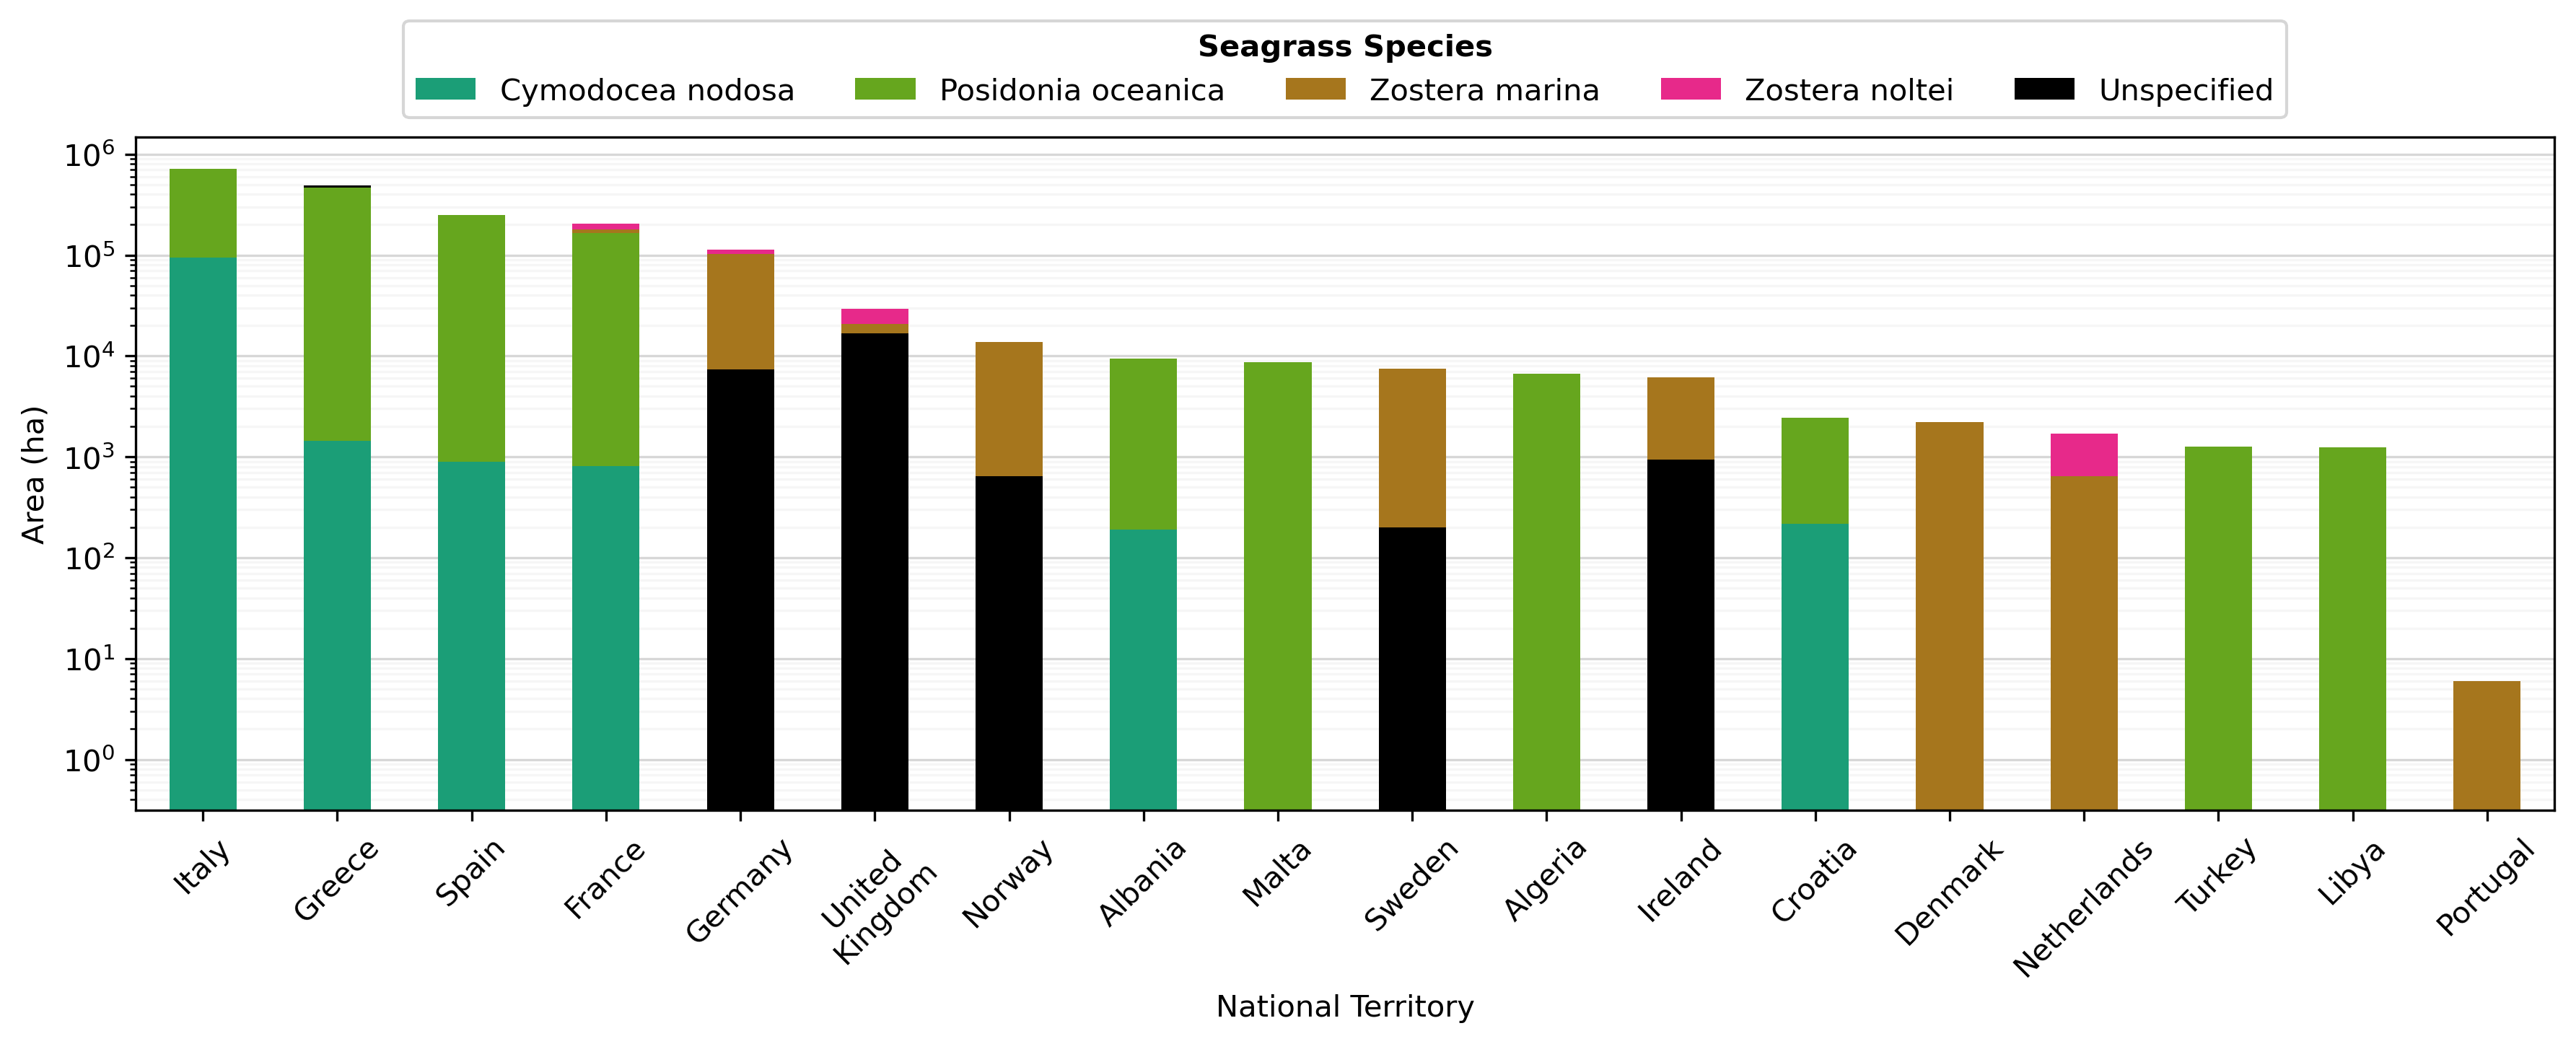

In [212]:
# plot a stacked bar chart by species type, ordered by total area
# Pivot table: index = territory, columns = species, values = area
stacked_areas = (
    g.groupby(["TERRITORY1", "seagrass_species"])["area_ha"].sum().unstack(fill_value=0)
)
# Order by total area
stacked_areas = stacked_areas.loc[
    stacked_areas.sum(axis=1).sort_values(ascending=False).index
]

# Reorder columns according to species_color_map if possible
species_order = [c for c in species_color_map if c in stacked_areas.columns] + [
    c for c in stacked_areas.columns if c not in species_color_map
]
stacked_areas = stacked_areas[species_order]

fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
stacked_areas.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[species_color_map.get(s, "#777777") for s in stacked_areas.columns],
    edgecolor="none",
)
plt.xticks(rotation=45)
plt.yscale("log")
ax.set_axisbelow(True)
ax.grid(True, which="major", axis="y", alpha=0.5)
ax.grid(True, which="minor", axis="y", alpha=0.1)
ax.set_xlabel("National Territory")
ax.set_ylabel("Area (ha)")
# replace " " with "\n" in the x-axis labels
xlabels = ax.get_xticklabels()
xlabels = [label.get_text().replace(" ", "\n") for label in xlabels]
ax.set_xticklabels(xlabels, ha="center")
# Rearrange legend handles/labels so "Unspecified" is last
handles, labels = ax.get_legend_handles_labels()
if "Unspecified" in labels:
    unspecified_index = labels.index("Unspecified")
    # Remove and append to end
    handles_unspecified = handles.pop(unspecified_index)
    labels_unspecified = labels.pop(unspecified_index)
    handles.append(handles_unspecified)
    labels.append(labels_unspecified)
legend = ax.legend(
    handles,
    labels,
    title="Seagrass Species",
    bbox_to_anchor=(0.5, 1.1),
    ncols=len(stacked_areas.columns),
    loc="center",
    borderaxespad=0.0,
)
# Set the legend title font to bold
if legend.get_title() is not None:
    legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()

In [220]:
# plot a stacked bar chart by species type, ordered by total area
# Pivot table: index = territory, columns = species, values = area
stacked_stocks = (
    g.groupby(["TERRITORY1", "seagrass_species"])["area_ha"].sum().unstack(fill_value=0)
)
# Order by total area
stacked_stocks = stacked_stocks.loc[
    stacked_stocks.sum(axis=1).sort_values(ascending=False).index
]

# Reorder columns according to species_color_map if possible
species_order = [c for c in species_color_map if c in stacked_stocks.columns] + [
    c for c in stacked_stocks.columns if c not in species_color_map
]
stacked_stocks = stacked_stocks[species_order]


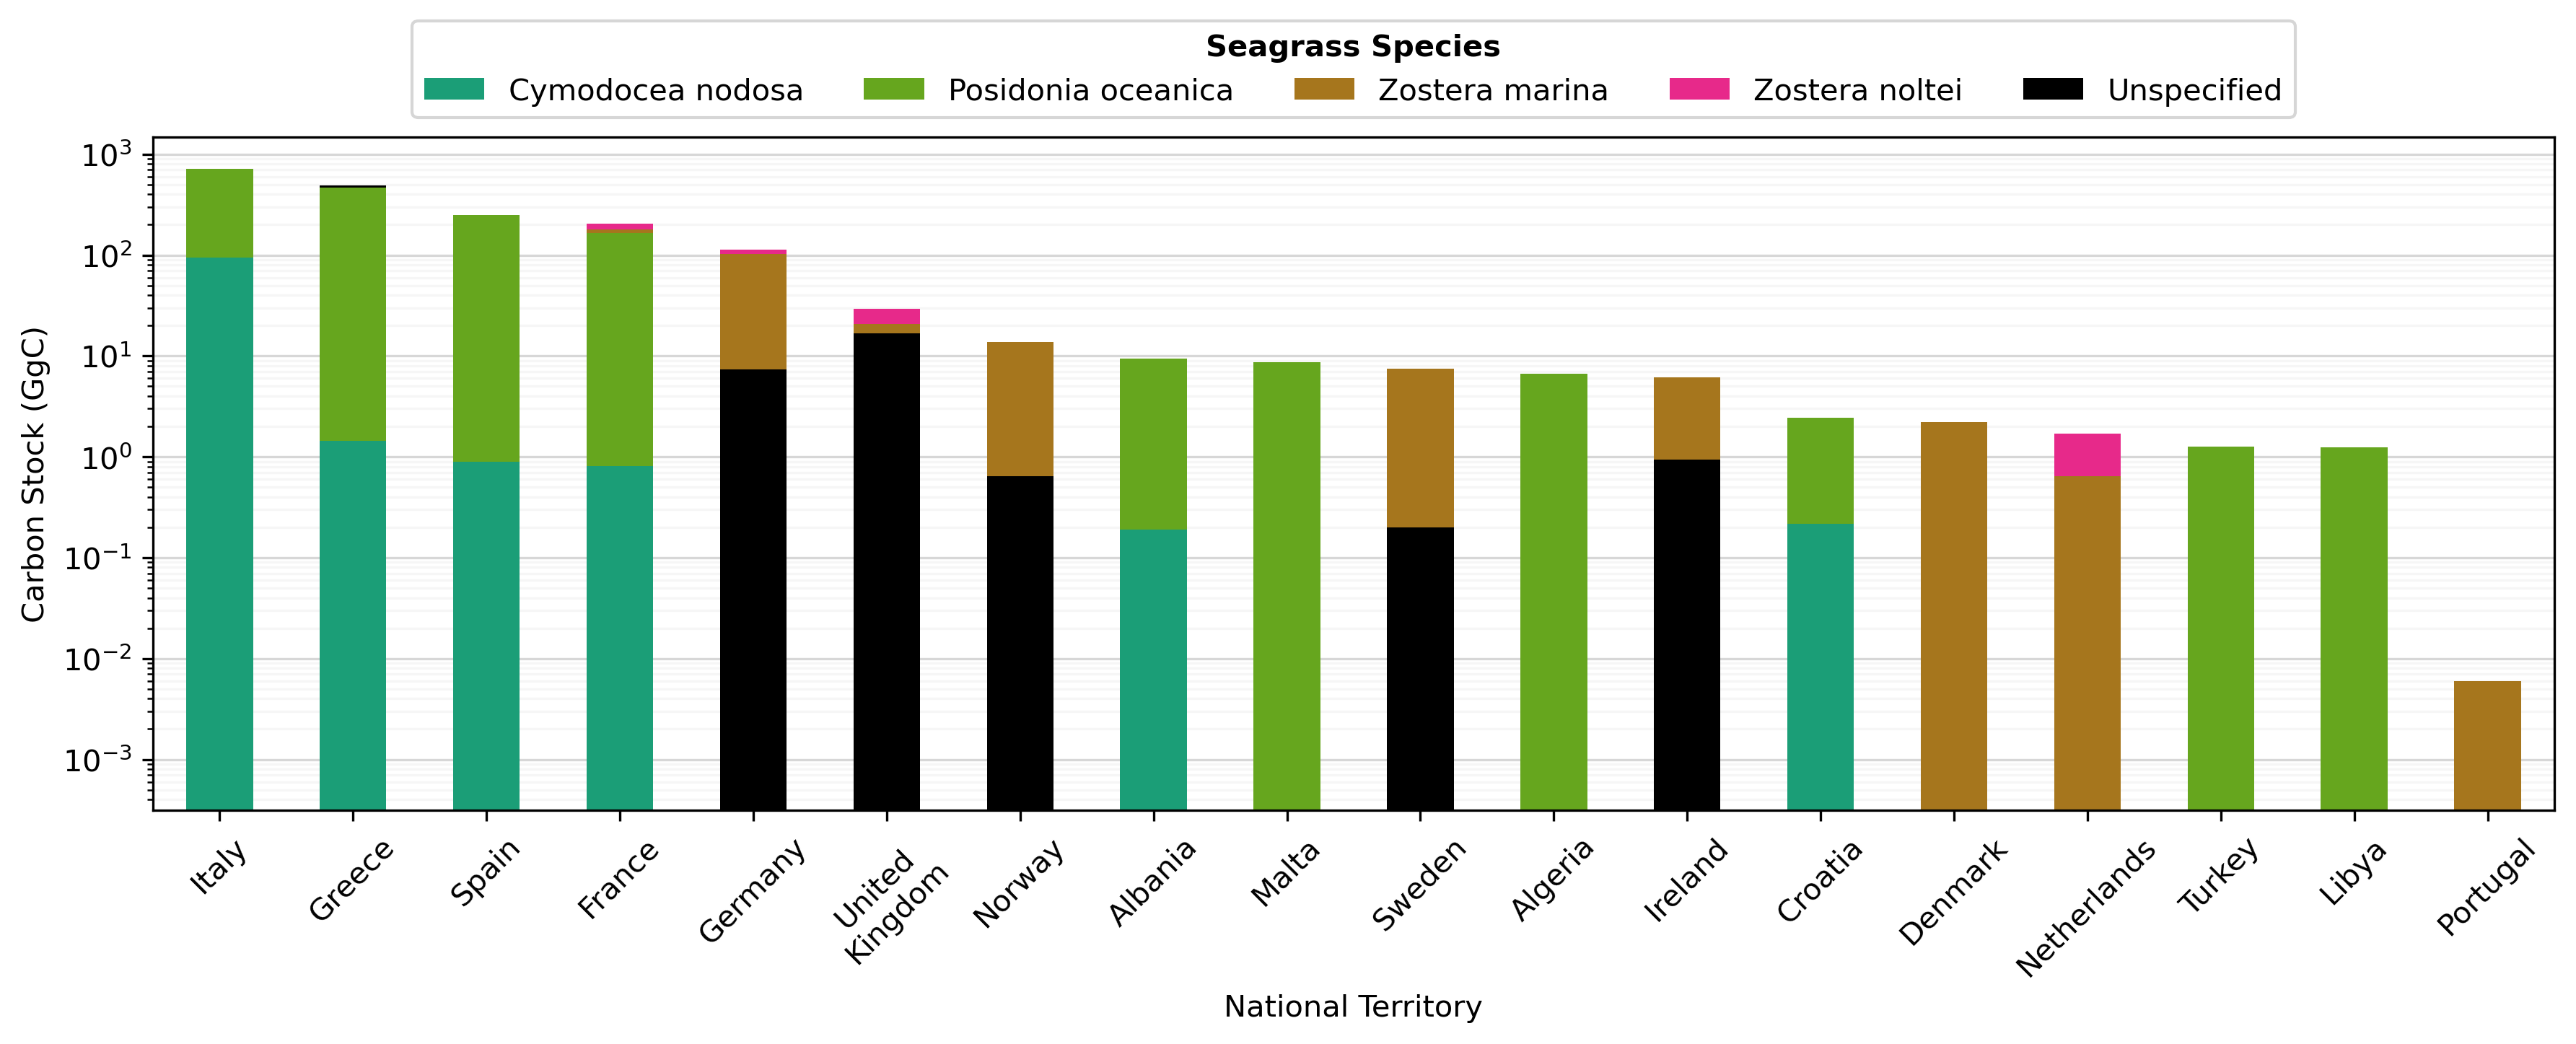

In [226]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

stacked_stocks_GC = stacked_stocks.copy() / 1e3

stacked_stocks_GC.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[species_color_map.get(s, "#777777") for s in stacked_stocks_GC.columns],
    edgecolor="none",
)

plt.xticks(rotation=45)
plt.yscale("log")
ax.set_axisbelow(True)
ax.grid(True, which="major", axis="y", alpha=0.5)
ax.grid(True, which="minor", axis="y", alpha=0.1)
ax.set_xlabel("National Territory")
ax.set_ylabel("Carbon Stock (GgC)")
# replace " " with "\n" in the x-axis labels
xlabels = ax.get_xticklabels()
xlabels = [label.get_text().replace(" ", "\n") for label in xlabels]
ax.set_xticklabels(xlabels, ha="center")
# Rearrange legend handles/labels so "Unspecified" is last
handles, labels = ax.get_legend_handles_labels()
if "Unspecified" in labels:
    unspecified_index = labels.index("Unspecified")
    # Remove and append to end
    handles_unspecified = handles.pop(unspecified_index)
    labels_unspecified = labels.pop(unspecified_index)
    handles.append(handles_unspecified)
    labels.append(labels_unspecified)
legend = ax.legend(
    handles,
    labels,
    title="Seagrass Species",
    bbox_to_anchor=(0.5, 1.1),
    ncols=len(stacked_areas.columns),
    loc="center",
    borderaxespad=0.0,
)
# Set the legend title font to bold
if legend.get_title() is not None:
    legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.show()


In [ ]:
# plot a bar chart, ordered by total carbon stock
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
values = national_areas.sort_values(ascending=False)

# from Mg to Gg
values = values / 1e3

values.plot(kind="bar", ax=ax)
plt.xticks(rotation=45)
plt.yscale("log")
ax.set_axisbelow(True)
ax.grid(True, which="major", axis="y", alpha=0.5)
ax.grid(True, which="minor", axis="y", alpha=0.1)
# replace " " with "\n" in the x-axis labels
labels = ax.get_xticklabels()
labels = [label.get_text().replace(" ", "\n") for label in labels]
ax.set_xticklabels(labels, ha="center")
ax.set_xlabel("National Territory")
ax.set_ylabel("Carbon Stock (GgC)")
plt.show()


KeyError: 'Column not found: carbon_stock_from_raster'

In [ ]:
ea_gdf_attributed_joined.geometry.area.sum() / 1e4  # from m2 to ha


2626713.4412855157

In [126]:
# save joined data to file
gdf_attributed_joined.to_file(
    SEAGRASS_EOV_FP / "gdf_attributed_joined.geojson", driver="GeoJSON"
)
pts_attributed_joined.to_file(
    SEAGRASS_EOV_FP / "points_attributed_joined.geojson", driver="GeoJSON"
)
print("Saved joined data to file")

Saved joined data to file


In [ ]:
pts_attributed_joined.TERRITORY1.isna()


0.11073811526959824

In [ ]:
gdf_carbon_stock = convert_carbon_density_to_carbon_stock(
    gdf_attributed["carbon_density_from_raster"], 100
)
pts_carbon_stock = convert_carbon_density_to_carbon_stock(
    pts_attributed["carbon_density_from_raster"], 100
)
gdf_attributed.loc[:, "carbon_stock_from_raster"] = gdf_carbon_stock
pts_attributed.loc[:, "carbon_stock_from_raster"] = pts_carbon_stock

In [84]:
# ------------------------------------------------------------------
# BUILD / LOAD CACHE
# ------------------------------------------------------------------

CACHE_DIR = Path("eov_cache")


def dynamic_buffer_distance(extent, frac=0.003, min_buf=0.0005, max_buf=0.06):
    xmin, xmax, ymin, ymax = extent
    scale = min(xmax - xmin, ymax - ymin)
    return float(np.clip(scale * frac, min_buf, max_buf))


def dynamic_point_size(extent, n_points, min_s=2.0, max_s=8.0):
    xmin, xmax, ymin, ymax = extent
    area = max((xmax - xmin) * (ymax - ymin), 1e-9)
    density = n_points / area  # points per degree^2

    # base size from panel scale (smaller for large panels)
    base = 0.18 * np.sqrt(area) + 1.2

    # downsize when very dense, upsize when sparse
    density_factor = 1 / (1.0 + 0.02 * np.sqrt(density))

    return float(np.clip(base * density_factor, min_s, max_s))


def auto_simplify_tolerance(extent, fraction=0.00001):
    xmin, xmax, ymin, ymax = extent
    return min(xmax - xmin, ymax - ymin) * fraction


def auto_buffer_distance(extent, fraction=0.02):
    xmin, xmax, ymin, ymax = extent
    return min(xmax - xmin, ymax - ymin) * fraction


def choose_tick_step(span, target=5):
    steps = np.array([0.25, 0.5, 1, 2, 2.5, 5, 10, 15, 20])
    ideal = max(span / max(target, 1), 1e-9)
    return float(steps[np.argmin(np.abs(steps - ideal))])


def clean_geoms(sub):
    sub = sub.copy()
    sub = sub[sub.geometry.notna() & ~sub.geometry.is_empty]
    # Make invalid geometries valid where possible
    sub["geometry"] = sub.geometry.map(make_valid)
    # Drop invalid/empty after repair
    sub = sub[sub.geometry.notna() & ~sub.geometry.is_empty]
    sub = sub[sub.geometry.is_valid]
    # Drop geometries with non-finite bounds
    b = sub.geometry.bounds
    finite = np.isfinite(b[["minx", "miny", "maxx", "maxy"]]).all(axis=1)
    sub = sub.loc[finite]
    return sub


def simplify_extent(gdf, extent, tolerance):
    xmin, xmax, ymin, ymax = extent
    sub = gdf.cx[xmin:xmax, ymin:ymax].copy()
    sub = clean_geoms(sub)
    sub["geometry"] = sub.geometry.simplify(tolerance, preserve_topology=True)
    sub = sub[sub.geometry.notna() & ~sub.geometry.is_empty]
    return sub


def get_simplified(
    name, gdf, extent, tolerance=None, buffer=None, force_recompute=False
):
    """
    Robust simplification and buffering. If topology-preserving simplify fails due to geometry errors,
    fallback to non-topology-preserving simplify, then filter out resulting invalid geometries.
    """
    tol = tolerance if tolerance is not None else auto_simplify_tolerance(extent)
    buf = buffer if buffer is not None else 0.0
    # Create base directory for this simplification value
    simpl_dir = CACHE_DIR / f"{name.replace(' ', '_')}_simp_tol_{tol:.6f}"
    simpl_dir.mkdir(parents=True, exist_ok=True)
    # Simplified (no buffer) cache path
    simplified_cache_path = simpl_dir / "simplified.pkl"
    # Directory for buffered versions under this simplification
    buf_dir = simpl_dir / "buffered"
    buf_dir.mkdir(parents=True, exist_ok=True)
    buffered_cache_path = buf_dir / f"buf_{buf:.6f}.pkl"

    if buf == 0.0:
        cache_path = simplified_cache_path
    else:
        cache_path = buffered_cache_path

    # Check if the target file already exists (buffered or not)
    if cache_path.exists() and not force_recompute:
        print(
            f"  [{name}] loading {'simplified' if buf == 0 else f'buffered (buf={buf})'} from cache"
        )
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    # Always check if the base simplification exists to avoid recomputing
    if simplified_cache_path.exists():
        print(f"  [{name}] reusing base simplification from cache for buffering step")
        with open(simplified_cache_path, "rb") as f:
            simp = pickle.load(f)
    else:
        print(f"  [{name}] simplifying (tol={tol:.6f})...")
        try:
            simp = simplify_extent(gdf, extent, tol)
        except Exception as e:
            # Try fallback with preserve_topology=False
            import warnings

            warnings.warn(
                f"Simplification with preserve_topology=True failed for {name}; "
                f"trying preserve_topology=False. Error: {e}"
            )
            xmin, xmax, ymin, ymax = extent
            sub = gdf.cx[xmin:xmax, ymin:ymax].copy()
            try:
                sub["geometry"] = sub.geometry.simplify(tol, preserve_topology=False)
            except Exception as e2:
                warnings.warn(
                    f"Fallback simplification with preserve_topology=False also failed for {name}. "
                    f"Dropping to original unsimplified geometry. Error: {e2}"
                )
                sub = sub[sub.geometry.notna() & ~sub.geometry.is_empty]
                simp = sub
            else:
                # Drop obviously bad, empty, or invalid simplified geometries
                sub = sub[sub.geometry.notna() & ~sub.geometry.is_empty]
                if hasattr(sub.geometry, "is_valid"):
                    sub = sub[sub.geometry.is_valid]
                simp = sub
        with open(simplified_cache_path, "wb") as f:
            pickle.dump(simp, f)

    if buf > 0.0:
        simp = simp.copy()
        print(f"  [{name}] buffering (buf={buf:.6f})...")
        simp["geometry"] = simp.geometry.buffer(buf)
        clip_box = box(extent[0], extent[2], extent[1], extent[3])
        simp["geometry"] = simp.geometry.intersection(clip_box)
        simp = simp[simp.geometry.notna() & ~simp.geometry.is_empty]
        if hasattr(simp.geometry, "is_valid"):
            simp = simp[simp.geometry.is_valid]
        with open(buffered_cache_path, "wb") as f:
            pickle.dump(simp, f)
    n_in = len(gdf.cx[extent[0] : extent[1], extent[2] : extent[3]])
    print(f"    {n_in} → {len(simp)} polygons retained")
    return simp


In [ ]:
# if "EXTENTS" not in globals():
EXTENTS = {
    "Europe": (-8.85, 33.3, 34.64, 60.11),
    "Crete": (23.5, 27.1, 34.5, 35.95),
    "UK": (-6, 1.5, 49, 51.5),
    "Sicily": (10.5, 17, 36, 39.5),
    "Baltic": (5, 13.5, 54, 59.5),
    "Tyrrhenian": (7, 11, 39, 43),
    "Spain": (-4, 3, 36, 42),
    "Aegean": (21, 28, 35.5, 41),
}  # lon_min, lon_max, lat_min, lat_max


Preparing panel data...
  [Europe] simplifying (tol=0.000010)...


/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_99699/2562174639.py:113: UserWarning: Simplification with preserve_topology=True failed for Europe; trying preserve_topology=False. Error: name 'make_valid' is not defined
  warnings.warn(
/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_99699/2562174639.py:130: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  sub = sub[sub.geometry.notna() & ~sub.geometry.is_empty]


  [Europe] buffering (buf=0.080000)...


/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_99699/2562174639.py:140: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  simp["geometry"] = simp.geometry.buffer(buf)


    592519 → 194054 polygons retained
  [Crete] simplifying (tol=0.000000)...
  [Crete] buffering (buf=0.030000)...


...

/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_99699/2562174639.py:113: UserWarning: Simplification with preserve_topology=True failed for Aegean; trying preserve_topology=False. Error: name 'make_valid' is not defined
  warnings.warn(
/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_99699/2562174639.py:130: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  sub = sub[sub.geometry.notna() & ~sub.geometry.is_empty]


  [Aegean] buffering (buf=0.050000)...


/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_99699/2562174639.py:140: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  simp["geometry"] = simp.geometry.buffer(buf)


    9796 → 9783 polygons retained
All data ready.



/Users/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/rt582/miniforge3/envs/shiftpy/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/rt582/miniforge3/envs

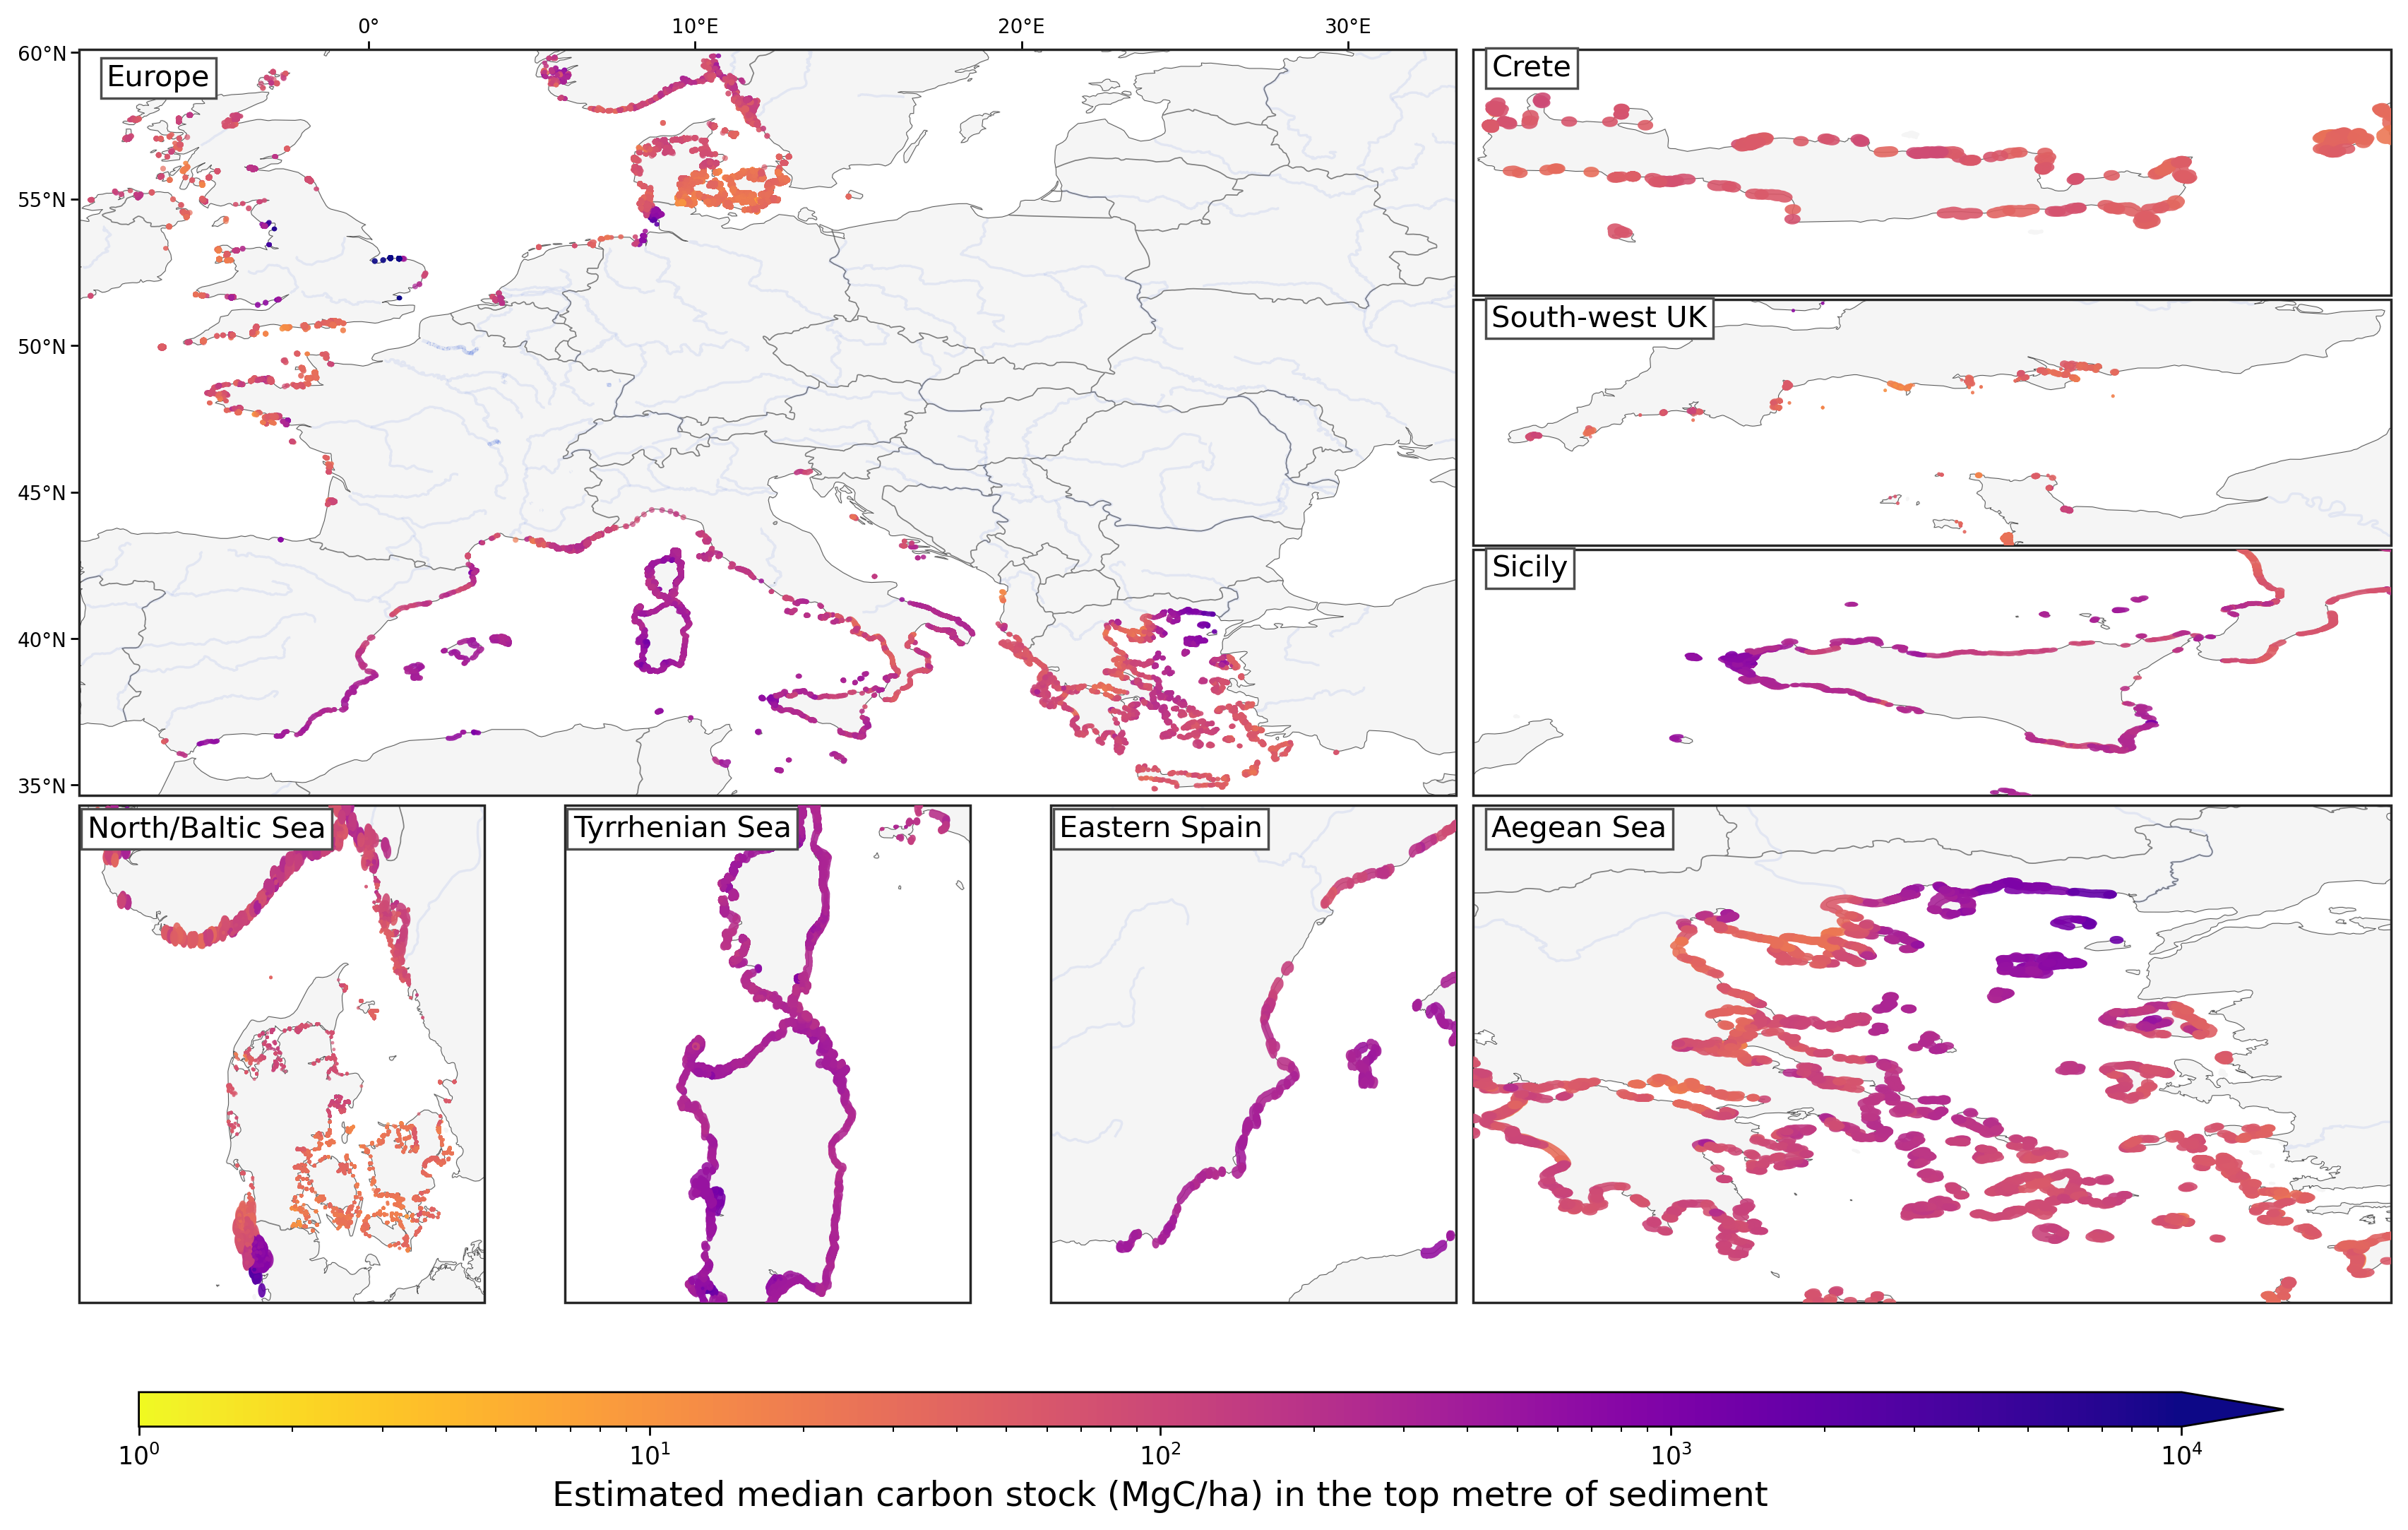

In [ ]:
# ============================================================
# Figure: multi-panel map with polygon + point geometries only
# Color shows attributed carbon density (log colorbar)
# ============================================================

# ------------------------------------------------------------------
# Preconditions / fallback config
# ------------------------------------------------------------------
if "gdf_attributed" not in globals():
    raise RuntimeError("`gdf_attributed` not found. Run attribution cell first.")
if "pts_attributed" not in globals():
    raise RuntimeError("`pts_attributed` not found. Run attribution cell first.")

TOLERANCES = {
    "Europe": 0.00001,
    "Crete": 0.0000001,
    "Baltic": 0.000001,
    "Scotland": 0.000001,
    "Tyrrhenian": 0.000001,
    "Aegean": 0.000001,
    "UK": 0.000001,
    "Spain": 0.000001,
    "Sicily": 0.000001,
    # "Palma": None,
    # "Rhodes": None,
}
BUFFERS = {
    "Europe": 0.08,
    "Crete": 0.03,
    "Baltic": 0.08,
    "Tyrrhenian": 0.03,
    "Aegean": 0.05,
    "UK": 0.03,
    "Spain": 0.06,
    "Sicily": 0.03,
    # "Scotland": 0.03,
    # "Palma": 0.008,
    # "Rhodes": 0.01,
}

# Ensure EPSG:4326
poly_gdf = gdf_attributed.copy()
pt_gdf = pts_attributed.copy()
if poly_gdf.crs is None:
    poly_gdf = poly_gdf.set_crs("EPSG:4326")
if pt_gdf.crs is None:
    pt_gdf = pt_gdf.set_crs("EPSG:4326")
if str(poly_gdf.crs).lower() not in {"epsg:4326", "4326"}:
    poly_gdf = poly_gdf.to_crs(4326)
if str(pt_gdf.crs).lower() not in {"epsg:4326", "4326"}:
    pt_gdf = pt_gdf.to_crs(4326)

poly_gdf = poly_gdf[poly_gdf.geometry.notna() & ~poly_gdf.geometry.is_empty].copy()
pt_gdf = pt_gdf[pt_gdf.geometry.notna() & ~pt_gdf.geometry.is_empty].copy()

# poly_val_col = "carbon_density_from_raster"
poly_val_col = "carbon_stock_from_raster"
pt_val_col = poly_val_col

if poly_val_col not in poly_gdf.columns:
    raise KeyError(f"Missing polygon value column: {poly_val_col}")
if pt_val_col not in pt_gdf.columns:
    raise KeyError(f"Missing point value column: {pt_val_col}")


print("Preparing panel data...")
rasters = {}
simplified = {}
for name, extent in EXTENTS.items():
    simplified_data = get_simplified(
        name,
        poly_gdf,
        extent,
        tolerance=TOLERANCES.get(name),
        buffer=BUFFERS.get(name, 0.0),
    )
    # remove nan values
    simplified[name] = simplified_data[simplified_data[poly_val_col].notna()]
    # # reorder df so that nan values are plotted first
    # simplified[name] = simplified_data.sort_values(
    #     "carbon_density_from_raster", na_position="last"
    # )
print("All data ready.\n")


# ------------------------------------------------------------------
# Shared log normalization across polygons + points
# ------------------------------------------------------------------
all_vals = np.r_[
    poly_gdf[poly_val_col].to_numpy(dtype=float),
    pt_gdf[pt_val_col].to_numpy(dtype=float),
]
pos_vals = all_vals[np.isfinite(all_vals) & (all_vals > 0)]
if pos_vals.size == 0:
    raise ValueError("No positive attributed values found for logarithmic colorbar.")


USE_LOG_COLORBAR = True

if poly_val_col == "carbon_stock_from_raster":
    LOG_VMIN = 1  # must be > 0 for log scale
    VMIN, VMAX = 0.0, 1e4
elif poly_val_col == "carbon_density_from_raster":
    LOG_VMIN = 1e-4  # must be > 0 for log scale
    VMIN, VMAX = 0.0, 0.25
else:
    raise ValueError(f"Invalid polygon value column: {poly_val_col}")


if USE_LOG_COLORBAR:
    norm = mpl.colors.LogNorm(vmin=LOG_VMIN, vmax=VMAX)
else:
    norm = mpl.colors.Normalize(vmin=VMIN, vmax=VMAX)

cmap = "plasma_r"
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
# ------------------------------------------------------------------
# Helpers (reuse if they already exist)
# ------------------------------------------------------------------


def choose_tick_step(span, target=5):
    steps = np.array([0.25, 0.5, 1, 2, 2.5, 5, 10, 15, 20])
    ideal = max(span / max(target, 1), 1e-9)
    return float(steps[np.argmin(np.abs(steps - ideal))])


def extent_grid_ticks(lo, hi, step):
    """Regular grid ticks that lie within [lo, hi] (avoids ticks past map extent)."""
    if step <= 0 or not (np.isfinite(lo) and np.isfinite(hi)):
        return np.array([])
    first = np.ceil(lo / step - 1e-12) * step
    last = np.floor(hi / step + 1e-12) * step
    if first > last:
        return np.array([])
    n = int(np.round((last - first) / step)) + 1
    return first + np.arange(n, dtype=float) * step


def style_map_axes(
    ax,
    extent,
    *,
    show_bottom=False,
    show_left=False,
    show_top=False,
    show_right=False,
    show_labels=False,
    target_ticks=4,
):
    xmin, xmax, ymin, ymax = extent
    xstep = choose_tick_step(xmax - xmin, target=target_ticks)
    ystep = choose_tick_step(ymax - ymin, target=target_ticks)
    xticks = extent_grid_ticks(xmin, xmax, xstep)
    yticks = extent_grid_ticks(ymin, ymax, ystep)
    if show_labels:
        ax.set_xticks(xticks, crs=ccrs.PlateCarree())
        ax.set_yticks(yticks, crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(
            LongitudeFormatter(
                number_format=".0f",
                degree_symbol="°",
                dateline_direction_label=False,
            )
        )
        ax.yaxis.set_major_formatter(
            LatitudeFormatter(number_format=".0f", degree_symbol="°")
        )
        ax.tick_params(
            axis="x",
            labelsize=8,
            pad=1.5,
            labelbottom=show_bottom,
            labeltop=show_top,
            bottom=False,
            top=True,
        )
        ax.tick_params(
            axis="y",
            labelsize=8,
            pad=1.5,
            labelleft=show_left,
            labelright=show_right,
            left=True,
            right=False,
        )
        # add grid behind the land and borders
        ax.grid(True, color="#f1f1f1", alpha=1, zorder=-10)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    ax.set_extent(extent, crs=ccrs.PlateCarree())


if "add_panel_label" not in globals():

    def add_panel_label(ax, text, fontsize=12):
        ax.text(
            0.02,
            0.98,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=fontsize,
            bbox=dict(facecolor="white", edgecolor="0.3", boxstyle="square,pad=0.2"),
            zorder=100,
        )


def draw_geom_panel(
    ax,
    name,
    extent,
    title,
    *,
    show_bottom=False,
    show_left=False,
    show_top=False,
    show_right=False,
    show_labels=False,
):
    xmin, xmax, ymin, ymax = extent
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.coastlines(linewidth=0.3, color="0.35")
    ax.add_feature(cfeature.LAND, color="#e5e5e5", alpha=1, zorder=0)
    ax.add_feature(cfeature.BORDERS, color="#a6a6a6", alpha=1, zorder=0, lw=0.5)
    ax.add_feature(
        cfeature.RIVERS.with_scale("10m"), color="royalblue", alpha=0.1, zorder=0
    )
    # add the Somme river
    somme_rows = rivers_gdf[rivers_gdf.name.str.contains("Somme", na=False)]
    somme_rows.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        color="royalblue",
        alpha=0.1,
        zorder=0,
    )

    # Use cached simplified/buffered polygons prepared once in get_simplified()
    poly_sub = simplified[name].copy()
    poly_sub = poly_sub.cx[xmin:xmax, ymin:ymax]
    pts_sub = pt_gdf.cx[xmin:xmax, ymin:ymax]

    # Dynamic per-panel point size (cheap)
    ms = dynamic_point_size(extent, n_points=len(pts_sub))

    # # Polygons colored by attributed value
    # if len(poly_sub) > 0:
    #     poly_sub.plot(
    #         ax=ax,
    #         transform=ccrs.PlateCarree(),
    #         column=poly_val_col,
    #         cmap=cmap,
    #         norm=norm,
    #         linewidth=0.25,
    #         alpha=0.9,
    #         zorder=10,
    #         missing_kwds={"color": "lightgrey"},
    #     )

    # Points colored by attributed value
    if len(pts_sub) > 0:
        xv = pts_sub.geometry.x.to_numpy()
        yv = pts_sub.geometry.y.to_numpy()
        vv = pts_sub[pt_val_col].to_numpy(dtype=float)
        ok = np.isfinite(vv) & (vv > 0)

        if np.any(ok):
            ax.scatter(
                xv[ok],
                yv[ok],
                c=vv[ok],
                s=ms,
                cmap=cmap,
                norm=norm,
                alpha=0.7,
                linewidths=0,
                transform=ccrs.PlateCarree(),
                zorder=20,
            )

    style_map_axes(
        ax,
        extent,
        show_bottom=show_bottom,
        show_left=show_left,
        show_top=show_top,
        show_right=show_right,
        show_labels=show_labels,
        target_ticks=4,
    )
    add_panel_label(ax, title)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_edgecolor("0.15")

    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_aspect("auto", adjustable="box")


# ------------------------------------------------------------------
# Figure layout (same structure as original multi-panel map)
# ------------------------------------------------------------------
fig = plt.figure(figsize=(13.5, 7.8), dpi=250)
outer = gridspec.GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[1.5, 1],
    height_ratios=[1.5, 1],
    left=0.025,
    right=0.995,
    bottom=0.08,  # leave room for colorbar
    top=0.99,
    wspace=0.015,
    hspace=0.015,
)

ax_main = fig.add_subplot(outer[0, 0], projection=ccrs.PlateCarree())
right_stack = outer[0, 1].subgridspec(3, 1, hspace=0.015)
ax_r1 = fig.add_subplot(right_stack[0, 0], projection=ccrs.PlateCarree())
ax_r2 = fig.add_subplot(right_stack[1, 0], projection=ccrs.PlateCarree())
ax_r3 = fig.add_subplot(right_stack[2, 0], projection=ccrs.PlateCarree())

bottom_stack = outer[1, 0].subgridspec(1, 3, hspace=0.015)
# To create non-equal width for the bottom row, redefine bottom_stack with custom width_ratios:
bottom_stack = outer[1, 0].subgridspec(1, 3, wspace=0.015, width_ratios=[1, 1, 1.5])
ax_b1 = fig.add_subplot(bottom_stack[0, 0], projection=ccrs.PlateCarree())
ax_b2 = fig.add_subplot(bottom_stack[0, 1], projection=ccrs.PlateCarree())
ax_b3 = fig.add_subplot(bottom_stack[0, 2], projection=ccrs.PlateCarree())
ax_br = fig.add_subplot(outer[1, 1], projection=ccrs.PlateCarree())

panel_specs = [
    (
        ax_main,
        "Europe",
        "Europe",
        dict(show_left=True, show_top=True, show_labels=True),
    ),
    (ax_r1, "Crete", "Crete", {}),
    (ax_r2, "UK", "South-west UK", {}),
    (ax_r3, "Sicily", "Sicily", {}),
    (ax_b1, "Baltic", "North/Baltic Sea", {}),
    (ax_b2, "Tyrrhenian", "Tyrrhenian Sea", {}),
    (ax_b3, "Spain", "Eastern Spain", {}),
    (ax_br, "Aegean", "Aegean Sea", {}),
]

for ax, name, title, kwargs in panel_specs:
    if name in EXTENTS:
        draw_geom_panel(ax, name, EXTENTS[name], title, **kwargs)

# # ------------------------------------------------------------------
# # UNIVERSAL COLORBAR
# # ------------------------------------------------------------------
# Create a ScalarMappable for the "prediction" dataset to use for colorbar
if USE_LOG_COLORBAR:
    norm = mpl.colors.LogNorm(vmin=LOG_VMIN, vmax=VMAX)
else:
    norm = mpl.colors.Normalize(vmin=VMIN, vmax=VMAX)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="plasma_r")

# Add a new axis for the colorbar beneath the figure
# Placement: below all axes, with reasonable margins
cbar_ax = fig.add_axes(
    [0.05, -0.01, 0.9, 0.025]
)  # [left, bottom, width, height] in fig fraction

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", extend="both", pad=0.08)
if poly_val_col == "carbon_stock_from_raster":
    cbar.set_label(
        "Estimated median carbon stock (MgC/ha) in the top metre of sediment",
        fontsize=14,
    )
else:
    cbar.set_label(
        "Estimated median carbon density (gC/cm³) in the top metre of sediment",
        fontsize=14,
    )
cbar.ax.tick_params(labelsize=10)

if USE_LOG_COLORBAR:
    if poly_val_col == "carbon_stock_from_raster":
        log_ticks = [1, 10, 100, 1000, 10000]
        cbar.set_ticks(log_ticks)
        cbar.set_ticklabels(
            [r"$10^{{{}}}$".format(int(np.log10(v))) for v in log_ticks], fontsize=10
        )
    else:
        log_ticks = [1e-4, 1e-3, 1e-2, 1e-1, 0.25]
        cbar.set_ticks(log_ticks)
        cbar.ax.set_xticklabels([f"{v:g}" for v in log_ticks], fontsize=10)
else:
    if poly_val_col == "carbon_stock_from_raster":
        lin_ticks = [1, 10, 100, 1000, 10000]
    else:
        lin_ticks = [0, 0.05, 0.10, 0.15, 0.20, 0.25]
    cbar.set_ticks(lin_ticks)
    cbar.ax.set_xticklabels([f"{v:.2f}" for v in lin_ticks], fontsize=10)